# Exploratory Data Analysis (EDA)

This notebook explores the processed dataset from `preprocessing.ipynb`. The goal is to understand feature distributions, spot patterns, and figure out which features might be useful for modelling.

## Workflow

1. Import libraries
2. Load processed data
3. Quick inspection: verify dataset, descriptive stats
4. Univariate analysis: distribution of each feature on its own
5. Bivariate analysis: how each feature relates to `Response`
6. Correlation analysis: heatmap + drill into the strongest pairs

## Step 1: Import required libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the processed training data (Parquet output of preprocessing.ipynb)


In [2]:
df_train = pd.read_parquet('data/processed/train_final.parquet')

## Step 3: Initial inspection of the processed dataset

In [3]:
# First 10 rows of the processed training set
df_train.head(10)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,0,21,1,35,0,1,1,65101,124,187,0
1,1,0,43,1,28,0,2,1,58911,26,288,1
2,2,1,25,1,14,1,0,0,38043,152,254,0
3,3,1,35,1,1,0,1,1,2630,156,76,0
4,4,1,36,1,15,1,1,0,31951,152,294,0
5,5,1,31,1,47,1,0,0,28150,152,197,0
6,6,0,23,1,45,1,0,0,27128,152,190,0
7,7,1,47,1,8,0,1,1,40659,26,262,1
8,8,1,26,1,28,1,0,0,31639,152,36,0
9,9,1,66,1,11,0,1,1,2630,26,125,0


In [4]:
# Descriptive statistics, confirms integer encoding and checks value ranges
df_train.describe()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,1.150480e+07,1.150480e+07,1.150480e+07,1.150480e+07,1.150480e+07,1.150480e+07,1.150480e+07,1.150480e+07,1.150480e+07,1.150480e+07,1.150480e+07,1.150480e+07
mean,5.752398e+06,4.586490e-01,3.838356e+01,9.980220e-01,2.641869e+01,4.629966e-01,6.031073e-01,5.026798e-01,3.046137e+04,1.124254e+02,1.638977e+02,1.229973e-01
std,3.321149e+06,4.982872e-01,1.499346e+01,4.443120e-02,1.299159e+01,4.986289e-01,5.678559e-01,4.999928e-01,1.645475e+04,5.403571e+01,7.997953e+01,3.284341e-01
min,0.000000e+00,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.630000e+03,1.000000e+00,1.000000e+01,0.000000e+00
25%,2.876199e+06,0.000000e+00,2.400000e+01,1.000000e+00,1.500000e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.527700e+04,2.900000e+01,9.900000e+01,0.000000e+00
50%,5.752398e+06,0.000000e+00,3.600000e+01,1.000000e+00,2.800000e+01,0.000000e+00,1.000000e+00,1.000000e+00,3.182400e+04,1.510000e+02,1.660000e+02,0.000000e+00
75%,8.628598e+06,1.000000e+00,4.900000e+01,1.000000e+00,3.500000e+01,1.000000e+00,1.000000e+00,1.000000e+00,3.945100e+04,1.520000e+02,2.320000e+02,0.000000e+00
max,1.150480e+07,1.000000e+00,8.500000e+01,1.000000e+00,5.200000e+01,1.000000e+00,2.000000e+00,1.000000e+00,5.401650e+05,1.630000e+02,2.990000e+02,1.000000e+00


## Step 4: Univariate analysis

Looking at each feature individually to check for skews, imbalances, outliers, etc.

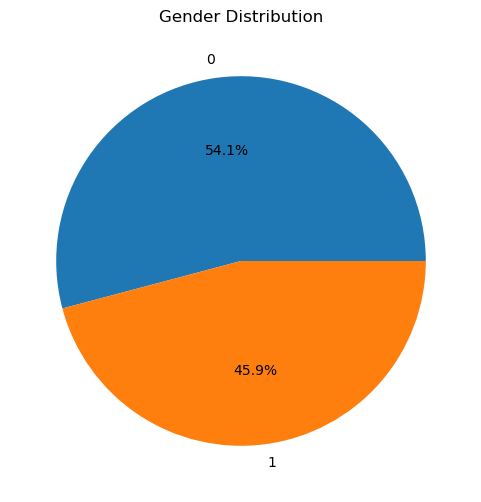

In [5]:
# Gender distribution, roughly balanced between male and female customers
df_train['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

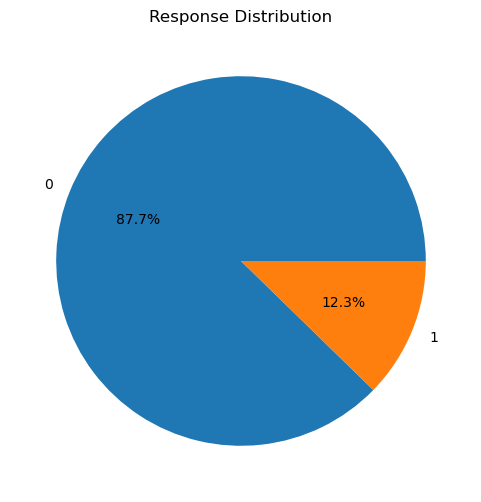

In [6]:
# Response distribution, confirms class imbalance (~12.3 % positive)
df_train['Response'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title('Response Distribution')
plt.ylabel('')
plt.show()

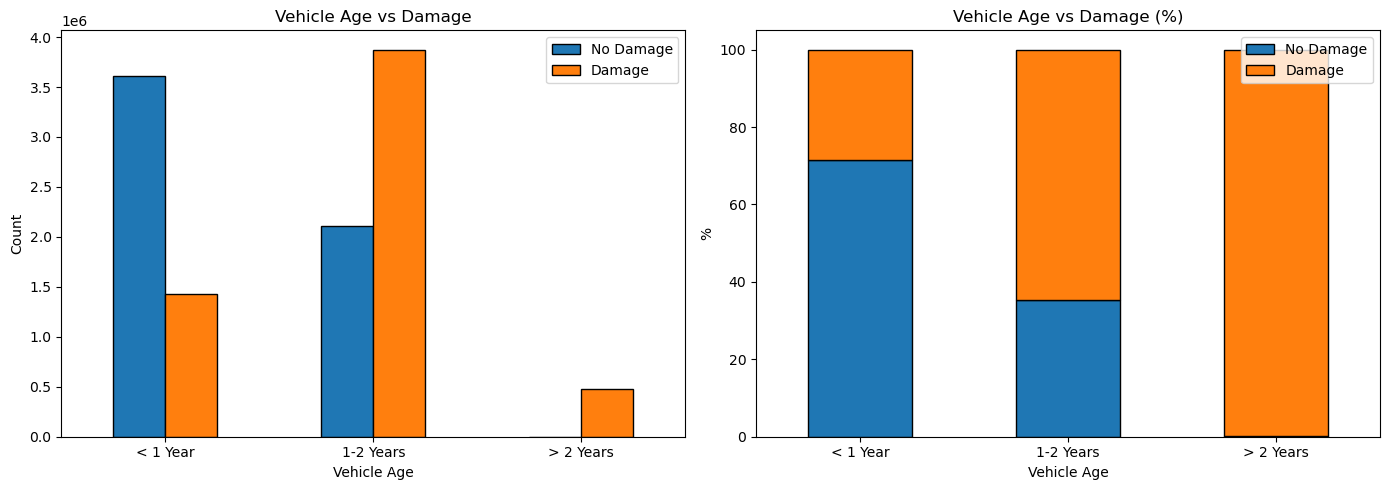

In [7]:
# Vehicle age vs vehicle damage. Left: absolute counts; right: damage rate by vehicle age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

damage_counts = pd.crosstab(df_train['Vehicle_Age'], df_train['Vehicle_Damage'])
damage_counts.index = ['< 1 Year', '1-2 Years', '> 2 Years']
damage_counts.columns = ['No Damage', 'Damage']

damage_counts.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Vehicle Age vs Damage')
axes[0].set_xlabel('Vehicle Age')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

damage_pct = damage_counts.div(damage_counts.sum(axis=1), axis=0) * 100
damage_pct.plot(kind='bar', stacked=True, ax=axes[1], edgecolor='black')
axes[1].set_title('Vehicle Age vs Damage (%)')
axes[1].set_xlabel('Vehicle Age')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

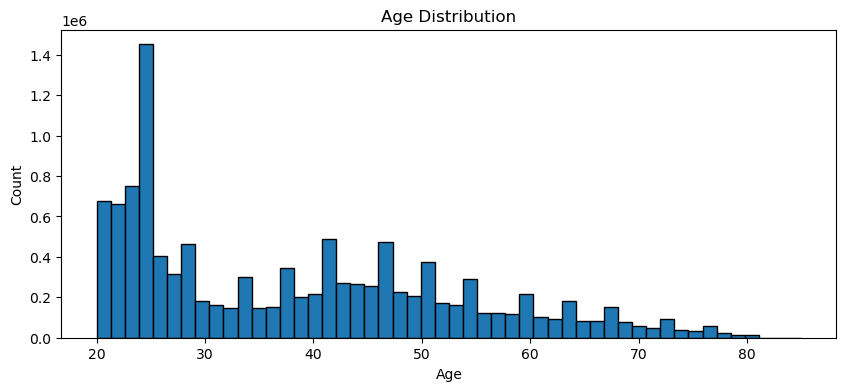

In [8]:
# Customer age distribution, roughly right-skewed, concentrated in the 20-50 range
plt.figure(figsize=(10, 4))
plt.hist(df_train['Age'], bins=50, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

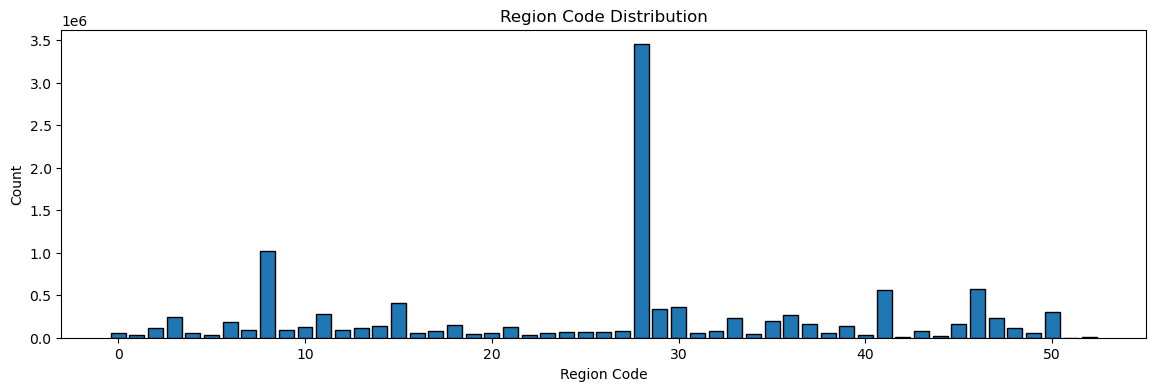

In [9]:
# Customer count per region, some regions are far more represented than others
region_counts = df_train['Region_Code'].value_counts().sort_index()

plt.figure(figsize=(14, 4))
plt.bar(region_counts.index, region_counts.values, edgecolor='black')
plt.title('Region Code Distribution')
plt.xlabel('Region Code')
plt.ylabel('Count')
plt.show()

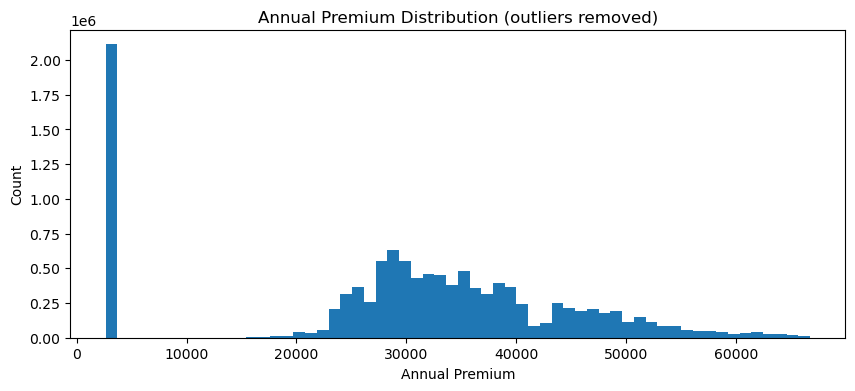

In [10]:
# remove top 1% outliers before plotting
p99 = df_train['Annual_Premium'].quantile(0.99)
data_clipped = df_train[df_train['Annual_Premium'] <= p99]['Annual_Premium']

plt.figure(figsize=(10, 4))
plt.hist(data_clipped, bins=60, edgecolor='none')
plt.title('Annual Premium Distribution (outliers removed)')
plt.xlabel('Annual Premium')
plt.ylabel('Count')
plt.show()


## Step 5: Bivariate analysis

Comparing feature distributions between customers who responded (`Response = 1`) and those who didn't, to see which features are most useful for prediction.

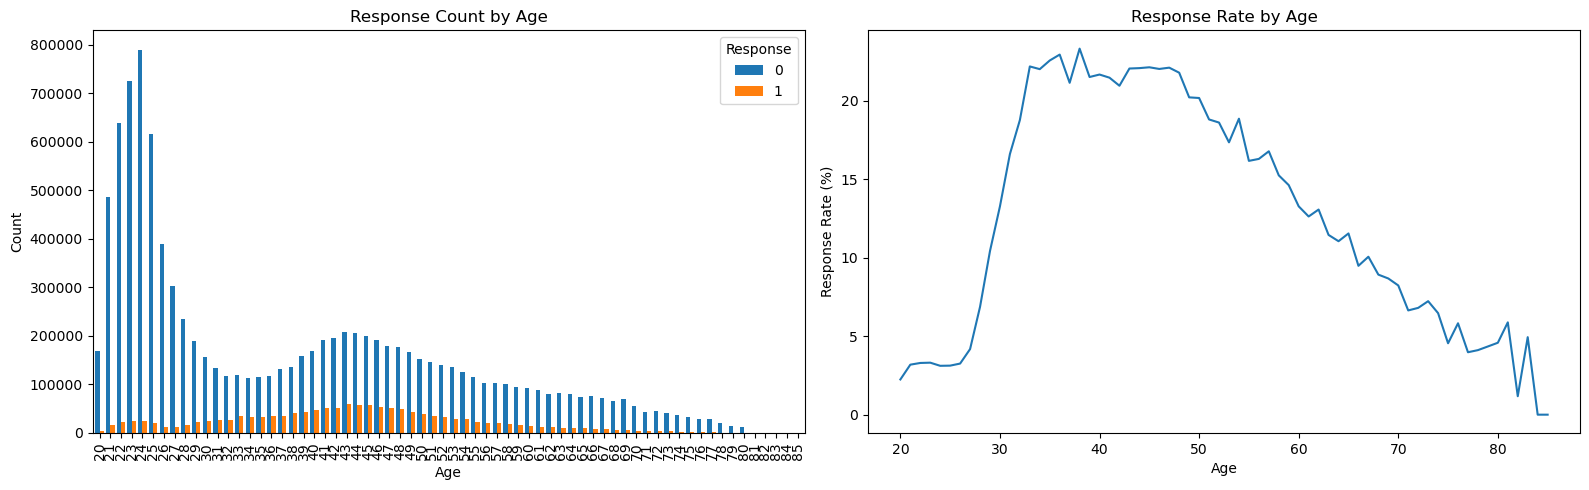

In [11]:
# Response count and response rate by customer age, shows which age groups are most receptive
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

age_response = df_train.groupby('Age')['Response'].value_counts().unstack(fill_value=0)
age_response.plot(kind='bar', ax=axes[0], edgecolor='none', width=0.8)
axes[0].set_title('Response Count by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)

response_rate = df_train.groupby('Age')['Response'].mean() * 100
axes[1].plot(response_rate.index, response_rate.values)
axes[1].set_title('Response Rate by Age')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Response Rate (%)')

plt.tight_layout()
plt.show()

Previously_Insured
0    22.849344
1     0.063830
Name: Response, dtype: float64


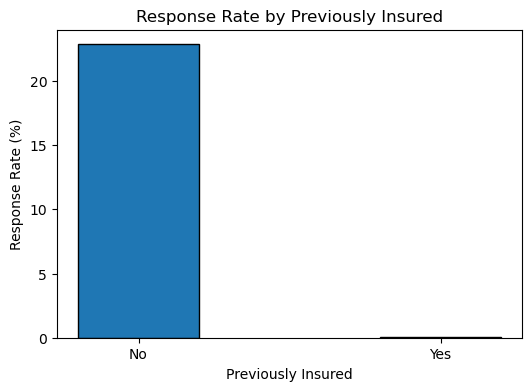

In [12]:
# Response rate by previously insured status, customers already insured rarely respond positively
response_rate_insured = df_train.groupby('Previously_Insured')['Response'].mean() * 100
print(response_rate_insured)

plt.figure(figsize=(6, 4))
plt.bar(['No', 'Yes'], response_rate_insured.values, edgecolor='black', width=0.4)
plt.title('Response Rate by Previously Insured')
plt.xlabel('Previously Insured')
plt.ylabel('Response Rate (%)')
plt.show()

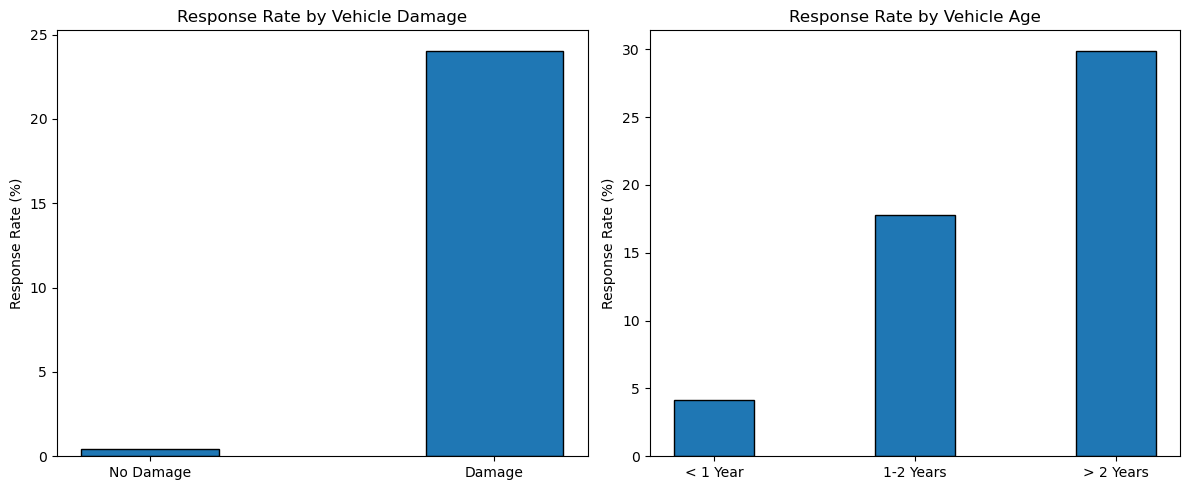

In [13]:
# Response rate by vehicle damage and vehicle age, damaged / older vehicles correlate with higher interest
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

response_by_damage = df_train.groupby('Vehicle_Damage')['Response'].mean() * 100
axes[0].bar(['No Damage', 'Damage'], response_by_damage.values, edgecolor='black', width=0.4)
axes[0].set_title('Response Rate by Vehicle Damage')
axes[0].set_ylabel('Response Rate (%)')

response_by_vehicle_age = df_train.groupby('Vehicle_Age')['Response'].mean() * 100
response_by_vehicle_age.index = ['< 1 Year', '1-2 Years', '> 2 Years']
axes[1].bar(response_by_vehicle_age.index, response_by_vehicle_age.values, edgecolor='black', width=0.4)
axes[1].set_title('Response Rate by Vehicle Age')
axes[1].set_ylabel('Response Rate (%)')

plt.tight_layout()
plt.show()

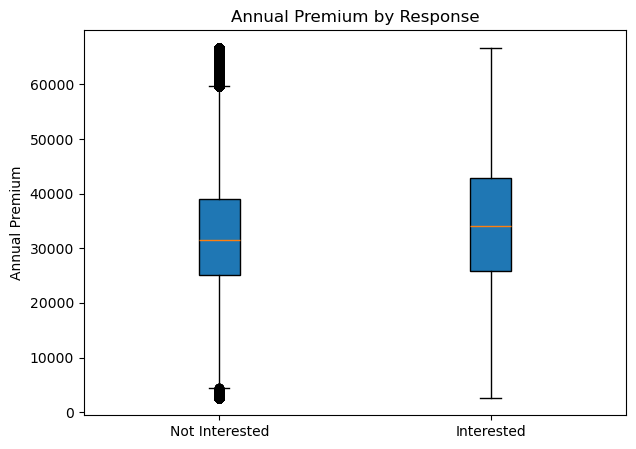

In [14]:
# Annual premium distribution by response, box plot (top-1 % outliers removed for readability)
data_box = df_train[df_train['Annual_Premium'] <= p99]

fig, ax = plt.subplots(figsize=(7, 5))
groups = [data_box[data_box['Response'] == r]['Annual_Premium'].values for r in [0, 1]]
ax.boxplot(groups, patch_artist=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Not Interested', 'Interested'])
ax.set_title('Annual Premium by Response')
ax.set_ylabel('Annual Premium')
plt.show()

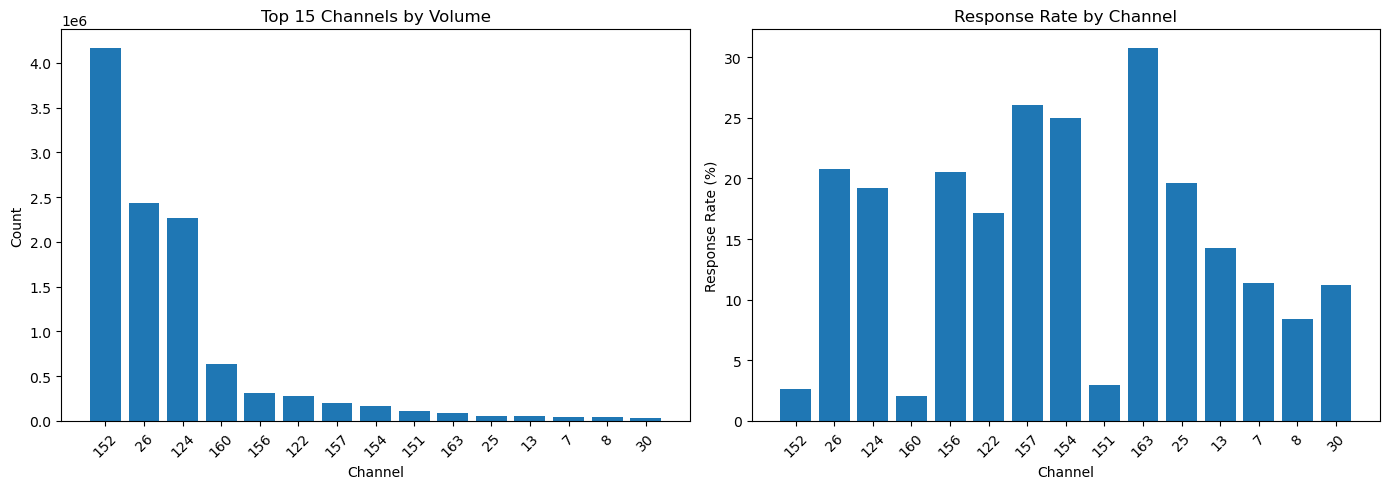

In [15]:
# Top 15 sales channels by customer volume and their corresponding response rates
top_channels = df_train['Policy_Sales_Channel'].value_counts().head(15)

response_by_channel = df_train[df_train['Policy_Sales_Channel'].isin(top_channels.index)] \
    .groupby('Policy_Sales_Channel')['Response'].mean() * 100
response_by_channel = response_by_channel.loc[top_channels.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(top_channels.index.astype(str), top_channels.values)
axes[0].set_title('Top 15 Channels by Volume')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(response_by_channel.index.astype(str), response_by_channel.values)
axes[1].set_title('Response Rate by Channel')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Response Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

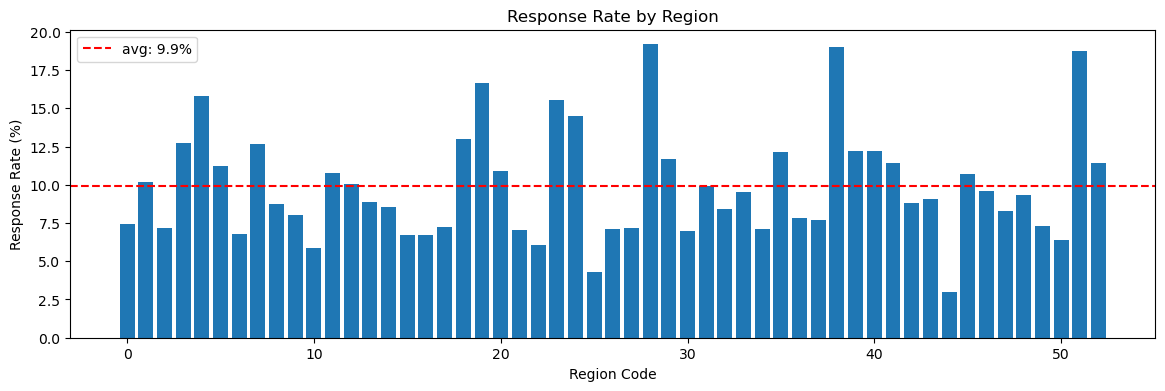

In [16]:
# Response rate per region, dashed red line marks the overall average (~9.9 %)
response_by_region = df_train.groupby('Region_Code')['Response'].mean() * 100

plt.figure(figsize=(14, 4))
plt.bar(response_by_region.index, response_by_region.values)
plt.axhline(response_by_region.mean(), color='red', linestyle='--', label=f'avg: {response_by_region.mean():.1f}%')
plt.title('Response Rate by Region')
plt.xlabel('Region Code')
plt.ylabel('Response Rate (%)')
plt.legend()
plt.show()

## Step 6: Correlation analysis

Pearson correlation heatmap, then a closer look at the two strongest pairs: `Previously_Insured` vs `Vehicle_Damage` (r ≈ −0.84) and `Age` vs `Vehicle_Age` (r ≈ 0.78).

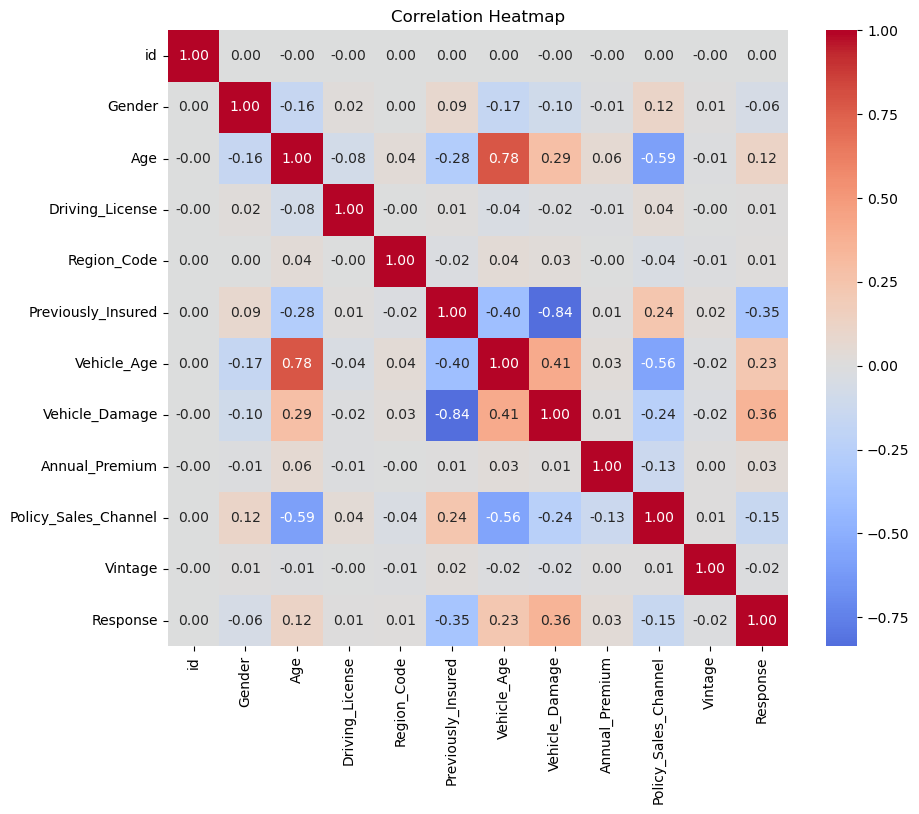

In [17]:
# Pearson correlation heatmap, highlights strong linear relationships between features
corr = df_train.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

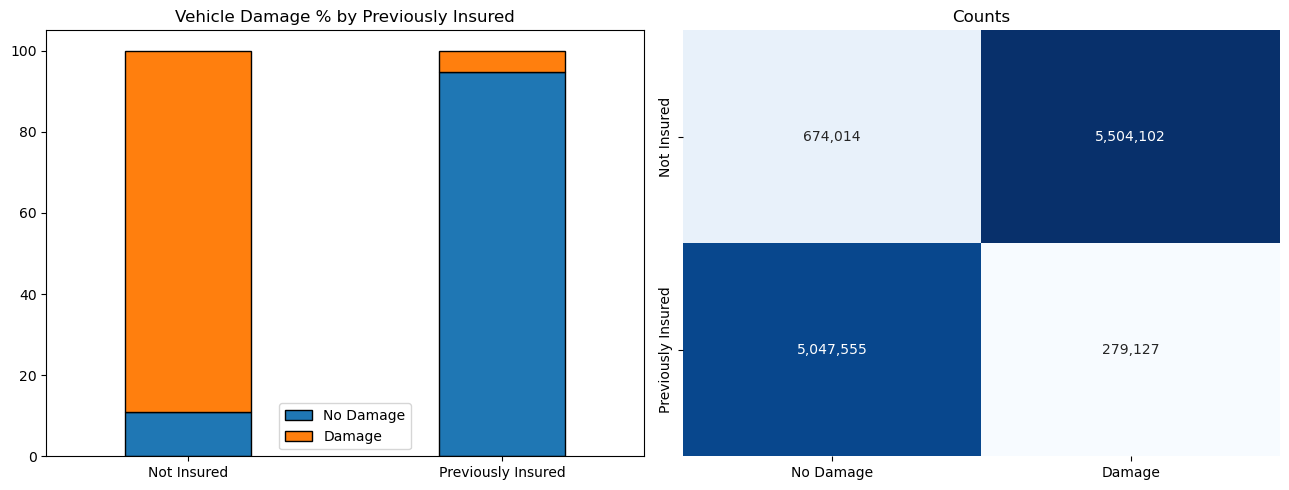

In [18]:
# Previously_Insured vs Vehicle_Damage (r ≈ -0.84)
# Customers who are already insured almost never report vehicle damage and vice versa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

insured_vs_damage = pd.crosstab(df_train['Previously_Insured'], df_train['Vehicle_Damage'], normalize='index') * 100
insured_vs_damage.index = ['Not Insured', 'Previously Insured']
insured_vs_damage.columns = ['No Damage', 'Damage']

insured_vs_damage.plot(kind='bar', stacked=True, ax=axes[0], edgecolor='black', width=0.4)
axes[0].set_title('Vehicle Damage % by Previously Insured')
axes[0].tick_params(axis='x', rotation=0)

insured_vs_damage_counts = pd.crosstab(df_train['Previously_Insured'], df_train['Vehicle_Damage'])
insured_vs_damage_counts.index = ['Not Insured', 'Previously Insured']
insured_vs_damage_counts.columns = ['No Damage', 'Damage']
sns.heatmap(insured_vs_damage_counts, annot=True, fmt=',', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Counts')

plt.tight_layout()
plt.show()

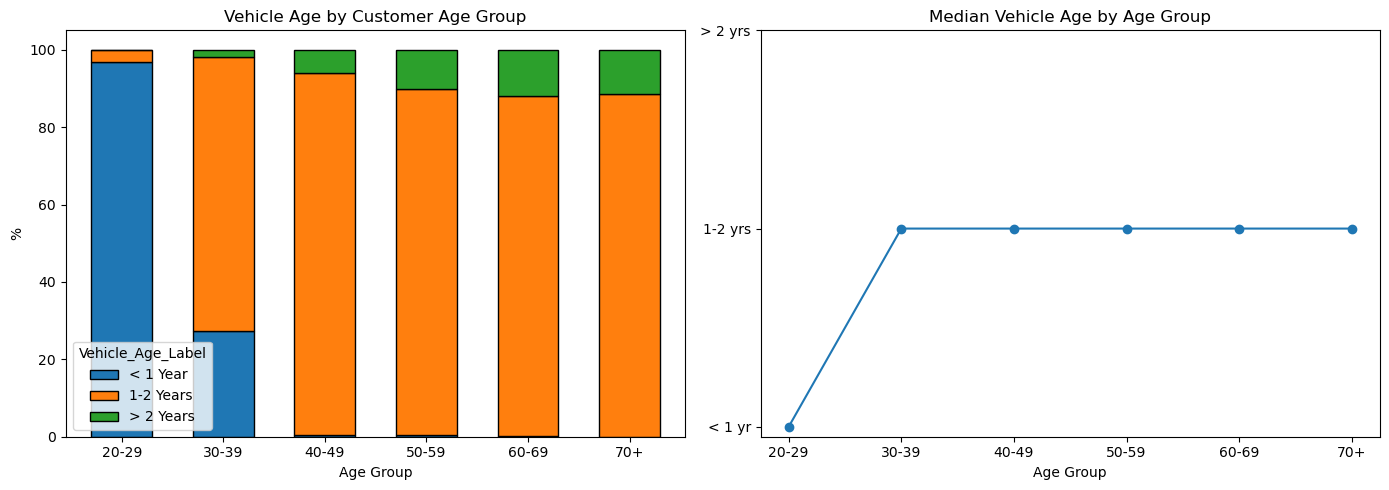

In [19]:
# Age vs Vehicle_Age (r ≈ 0.78)
# Older customers tend to own older vehicles
age_bins = [20, 30, 40, 50, 60, 70, 85]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70+']
df_train['Age_Group'] = pd.cut(df_train['Age'], bins=age_bins, labels=age_labels, right=False)

vage_map = {0: '< 1 Year', 1: '1-2 Years', 2: '> 2 Years'}
df_train['Vehicle_Age_Label'] = df_train['Vehicle_Age'].map(vage_map)

age_vs_vehicle_age = pd.crosstab(df_train['Age_Group'], df_train['Vehicle_Age_Label'], normalize='index') * 100
age_vs_vehicle_age = age_vs_vehicle_age[['< 1 Year', '1-2 Years', '> 2 Years']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_vs_vehicle_age.plot(kind='bar', stacked=True, ax=axes[0], edgecolor='black', width=0.6)
axes[0].set_title('Vehicle Age by Customer Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)

median_vage = df_train.groupby('Age_Group', observed=True)['Vehicle_Age'].median()
axes[1].plot(median_vage.index, median_vage.values, marker='o')
axes[1].set_title('Median Vehicle Age by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['< 1 yr', '1-2 yrs', '> 2 yrs'])

plt.tight_layout()
plt.show()